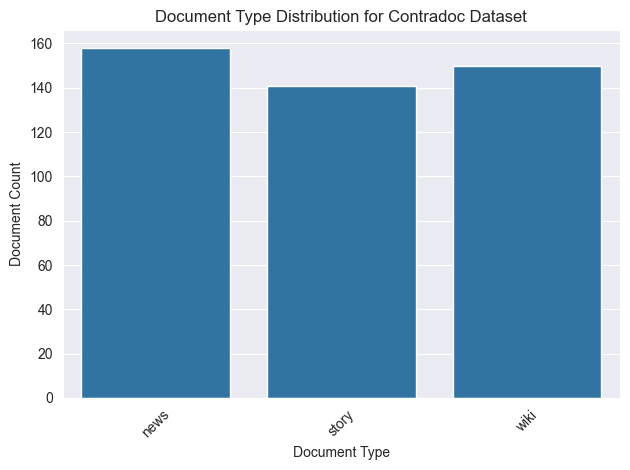

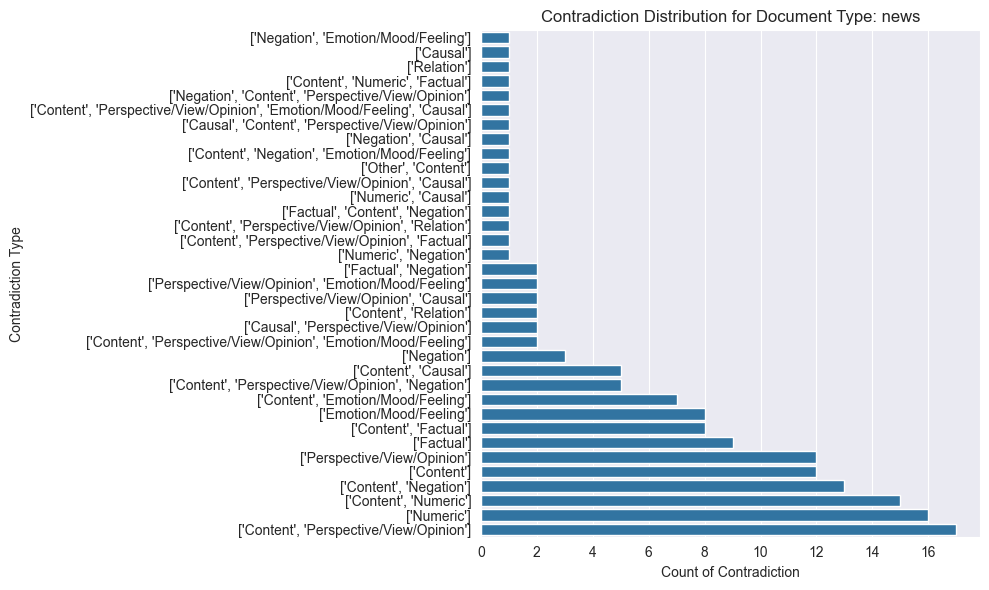

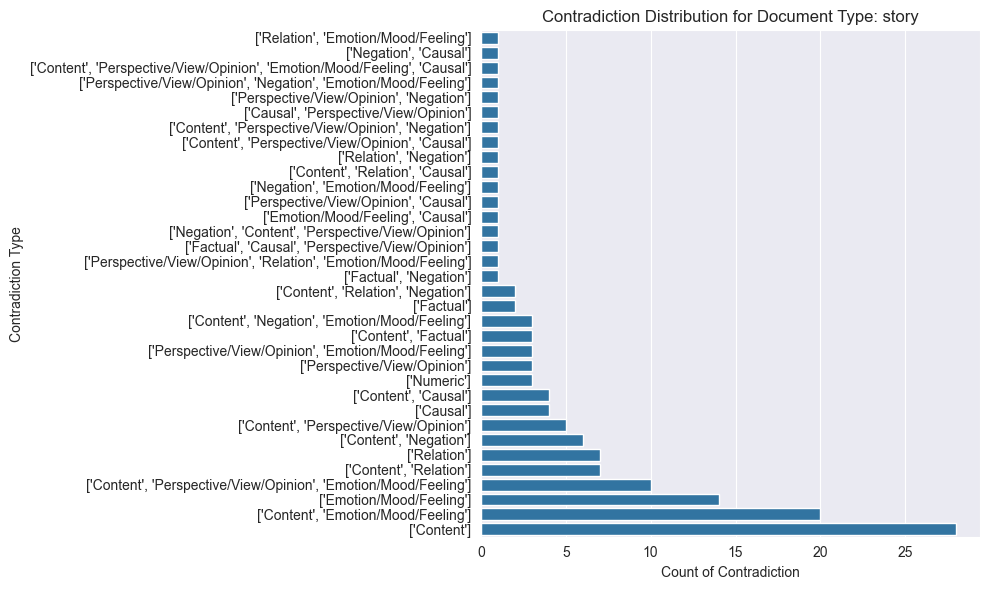

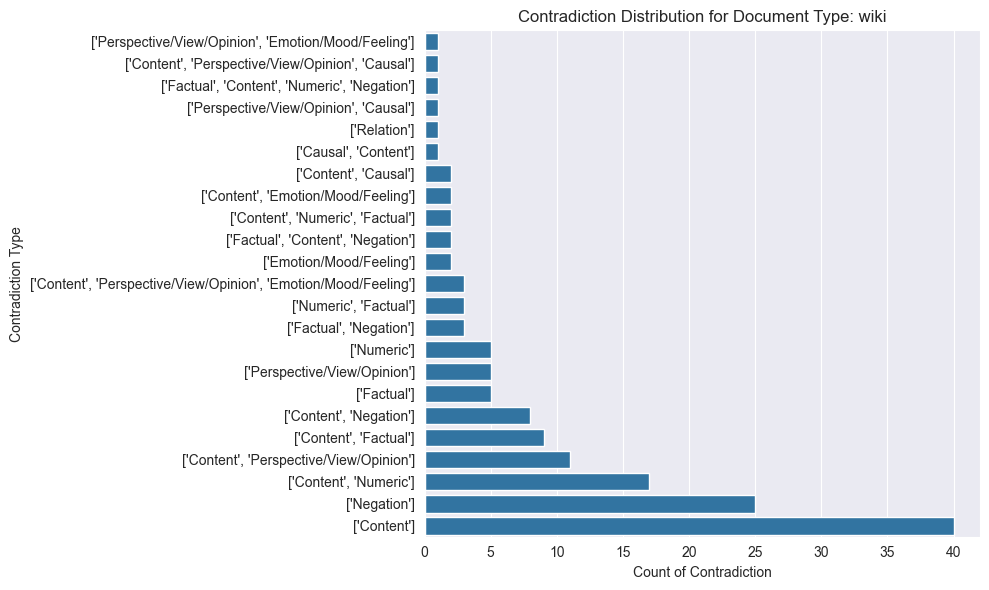

In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def load_dataset(path: str) -> pd.DataFrame:
    with open(path, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data["pos"]).T
    df["contra_type"] = df["contra_type"].astype(str)
    return df

def plot_doc_type_distribution(df: pd.DataFrame) -> None:
    plt.figure()
    sns.countplot(data=df, x="doc_type")
    plt.title("Document Type Distribution for Contradoc Dataset")
    plt.xlabel("Document Type")
    plt.ylabel("Document Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_contra_distribution_by_doc_type(df: pd.DataFrame) -> None:
    for doc_type in df["doc_type"].unique():
        sub_df = df[df["doc_type"] == doc_type]
        order = sub_df["contra_type"].value_counts(ascending=True).index

        plt.figure(figsize=(10, 6))
        sns.countplot(data=sub_df, y="contra_type", order=order)

        plt.title(f"Contradiction Distribution for Document Type: {doc_type}")
        plt.xlabel("Count of Contradiction")
        plt.ylabel("Contradiction Type")
        plt.tight_layout()
        plt.show()


def main():
    df = load_dataset("datasets/ContraDoc/ContraDoc.json")
    df = df.sort_values("doc_type")
    plot_doc_type_distribution(df)
    plot_contra_distribution_by_doc_type(df)


if __name__ == "__main__":
    main()